# Imaging-systematics weights via multilinear regression — refactored
Pixel-level (nside=64) WLS regression of galaxy overdensity against imaging systematics,
producing per-galaxy weight maps for the binned w(θ) pipeline.

The numerics live in `sys_weights.py` (importable, so the binned w(θ) notebook can refit
per property bin with the same machinery). This notebook is the driver + diagnostics.

**Method fixes vs. the original** (each explained at the relevant cell):
ngal=0 pixels kept in the fit; variance from expected counts; intercept term; standardised
features; no dense N×N weight matrix; coverage cut; fit-footprint mask exported alongside the
weight map; one dec split shared with the clustering pipeline; both regions run in one loop
(no manual `part=` flipping and stale-state cells); output filenames match what the w(θ)
notebook reads.

In [13]:
import os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import scienceplots
from sys_weights import SysWeights, points_to_map, DEFAULT_SYSTEMATICS

plt.style.use(['science', 'notebook', 'grid'])

# ── Config ───────────────────────────────────────────────────────────────────
SYS_DIR   = '../imaging_systematics_maps_new/data'
DATA_PATH = '../table_match_final.fits'
OUT_DIR   = '/user/animesh.sah/DESI_PECVEL/systematic_weights'   # where w(θ) reads from
NSIDE     = 64
DEC_SPLIT = 32.375        # SAME split as the clustering pipeline (was 32.3 here — the
                          # 32.3–32.375 strip got weights from the wrong region's map)
COVERAGE_MIN = 0.2        # was tr=0.0: boundary pixels with tiny random coverage have
                          # delta-variance the Poisson model underestimates — cut them
OUTLIER_KIND = 'none'
WEIGHT_KIND  = OUTLIER_KIND        # tag used in output filenames
RIDGE = 0.0               # try e.g. 1e2 if the collinear PSFDEPTH coeffs look unstable
EXTRAPOLATE = True        # keep outlier pixels in the analysis with model-
                          # extrapolated weights (coefficients still trained on the
                          # cut footprint). MUST be validated: see the
                          # 'Extrapolation validation' cell — if the all-pixel null
                          # tests fail or extrap_clipped_frac is large, set False
#QUADRATIC = ['Stellar_Density_AllWISE', 'PSFDEPTH_W1']   # curvature terms
SYSTEMATICS = DEFAULT_SYSTEMATICS
os.makedirs(OUT_DIR, exist_ok=True)

import fitsio
from astropy.table import Table
gal = Table(fitsio.FITS(DATA_PATH)[1].read())
RA_g, DEC_g = np.asarray(gal['RA'], float), np.asarray(gal['DEC'], float)
print(f"{len(gal):,} galaxies")

472,561 galaxies


## Fit both regions in one loop
The original notebook was run by hand-editing `part='north'`/`'south'` and re-executing —
with the commented-out `coeffs_north_... = coeffs` bookkeeping cells as a symptom. One loop,
one dict, no stale state.

Reading the fit summary: **χ²/dof before → after**. "Before" is the null hypothesis that the
overdensity field is pure Poisson noise + systematics; after a good fit it should approach
the value expected from Poisson + real clustering. If it plunges *far* below the before value
with only 11 linear terms, suspect overcorrection.

In [14]:
SW, FIT = {}, {}
for part in ('north', 'south'):
    SW[part] = SysWeights(
        part=part,
        mask_path=f'../mask_psf_{part}_nside_64.fits',
        sys_dir=SYS_DIR,
        rand_counts_path=f'{SYS_DIR}/{part}_counts_randoms_nside_64.fits',
        systematics=SYSTEMATICS, nside=NSIDE,
        coverage_min=COVERAGE_MIN, outlier_kind=OUTLIER_KIND,
        quadratic=[])

    reg = (DEC_g >= DEC_SPLIT) if part == 'north' else (DEC_g < DEC_SPLIT)
    FIT[part] = SW[part].fit(RA_g[reg], DEC_g[reg], ridge=RIDGE,
                             extrapolate=EXTRAPOLATE)

    f = FIT[part]
    print(f"\n{part.upper()}  ({reg.sum():,} galaxies, "
          f"{len(SW[part].fit_pixels):,} fit pixels)")
    print(f"  chi2/dof: {f['chi2_before']/f['ndof']:.2f} -> "
          f"{f['chi2_after']/f['ndof']:.2f}")
    print(f"  weight footprint: {f['weight_pixel_mask'].sum():,} pix "
          f"(fit on {f['fit_pixel_mask'].sum():,}); "
          f"clip-saturated extrapolated pixels: {f['extrap_clipped_frac']:.1%}")


NORTH  (141,740 galaxies, 6,009 fit pixels)
  chi2/dof: 8.82 -> 8.38
  weight footprint: 6,009 pix (fit on 6,009); clip-saturated extrapolated pixels: 0.0%

SOUTH  (330,821 galaxies, 13,393 fit pixels)
  chi2/dof: 9.53 -> 9.41
  weight footprint: 13,393 pix (fit on 13,393); clip-saturated extrapolated pixels: 0.0%


## Coefficients
Features are standardised (zero mean, unit variance) before fitting, so coefficients are
directly comparable across systematics — in the original, raw-unit coefficients made e.g.
CSFD (values ≪ 1) look enormous next to PSFDEPTH (values ≫ 1) for the same physical effect.
An intercept is included (centered features without one let the collinear PSFDEPTH block
absorb the mean offset).

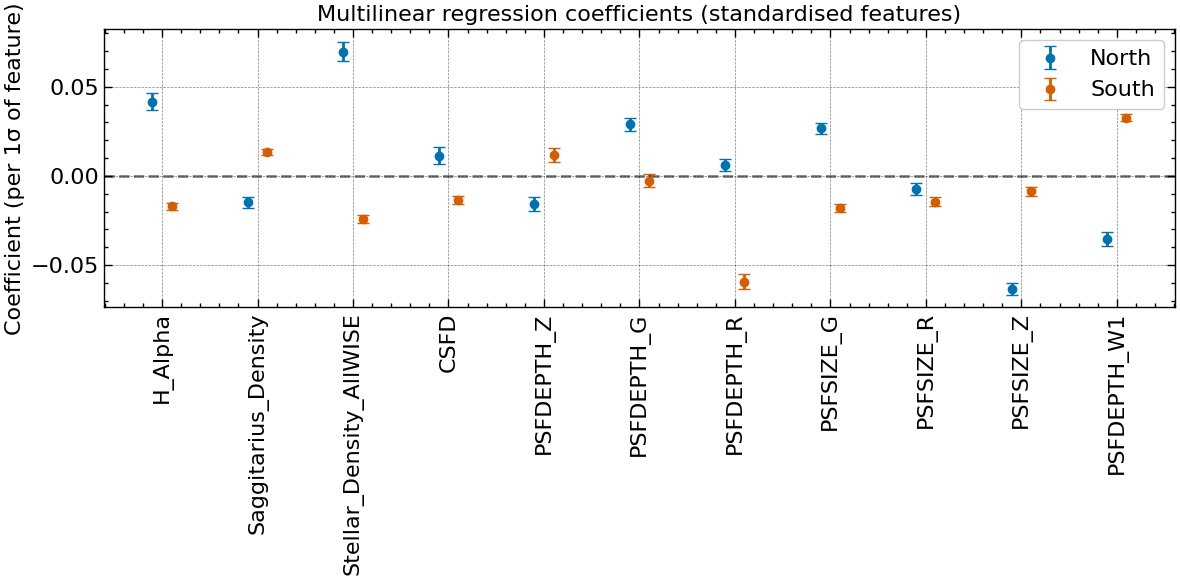


NORTH: intercept = 0.00046 (should be ~0 if delta is well normalised)
  H_Alpha                       : +0.04172 ± 0.00484   (8.6σ)
  Saggitarius_Density           : -0.01488 ± 0.00287   (5.2σ)
  Stellar_Density_AllWISE       : +0.06977 ± 0.00540   (12.9σ)
  CSFD                          : +0.01124 ± 0.00480   (2.3σ)
  PSFDEPTH_Z                    : -0.01594 ± 0.00392   (4.1σ)
  PSFDEPTH_G                    : +0.02893 ± 0.00376   (7.7σ)
  PSFDEPTH_R                    : +0.00629 ± 0.00340   (1.9σ)
  PSFSIZE_G                     : +0.02661 ± 0.00312   (8.5σ)
  PSFSIZE_R                     : -0.00718 ± 0.00329   (2.2σ)
  PSFSIZE_Z                     : -0.06325 ± 0.00340   (18.6σ)
  PSFDEPTH_W1                   : -0.03541 ± 0.00368   (9.6σ)

SOUTH: intercept = -0.00011 (should be ~0 if delta is well normalised)
  H_Alpha                       : -0.01697 ± 0.00196   (8.6σ)
  Saggitarius_Density           : +0.01338 ± 0.00186   (7.2σ)
  Stellar_Density_AllWISE       : -0.02408 ± 0.00

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(SYSTEMATICS))
for part, c, off in (('north', '#0072B2', -0.1), ('south', '#D55E00', +0.1)):
    ax.errorbar(x + off, FIT[part]['coeffs'], yerr=FIT[part]['errors'],
                fmt='o', capsize=4, label=part.capitalize(), color=c)
ax.axhline(0, color='k', ls='--', alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(SYSTEMATICS, rotation=90)
ax.set_ylabel('Coefficient (per 1σ of feature)')
ax.set_title('Multilinear regression coefficients (standardised features)')
ax.legend(); plt.tight_layout(); plt.show()

for part in FIT:
    print(f"\n{part.upper()}: intercept = {FIT[part]['intercept']:.5f} "
          f"(should be ~0 if delta is well normalised)")
    for s, c, e in zip(SYSTEMATICS, FIT[part]['coeffs'], FIT[part]['errors']):
        print(f"  {s:30s}: {c:+.5f} ± {e:.5f}   ({abs(c)/e:.1f}σ)")

## Feature correlation
Kept from the original — with |r| ≳ 0.9 inside the PSFDEPTH block, individual coefficients
trade off against each other even though the *prediction* (what the weights use) is stable.
If the coefficient errors on that block look wild, set `RIDGE > 0` above; it regularises the
coefficients without materially changing the predicted contamination map.

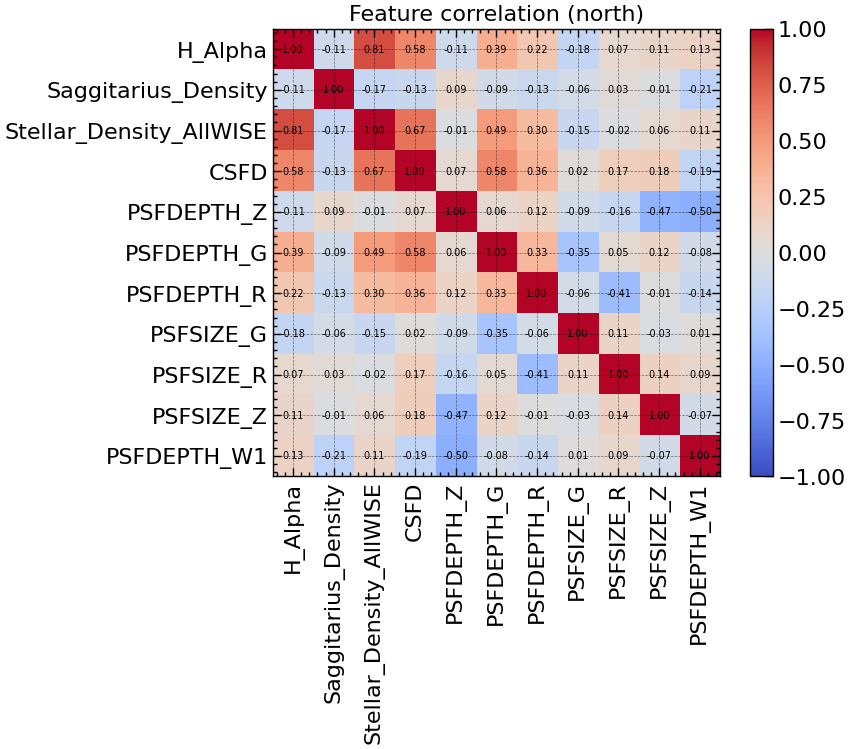

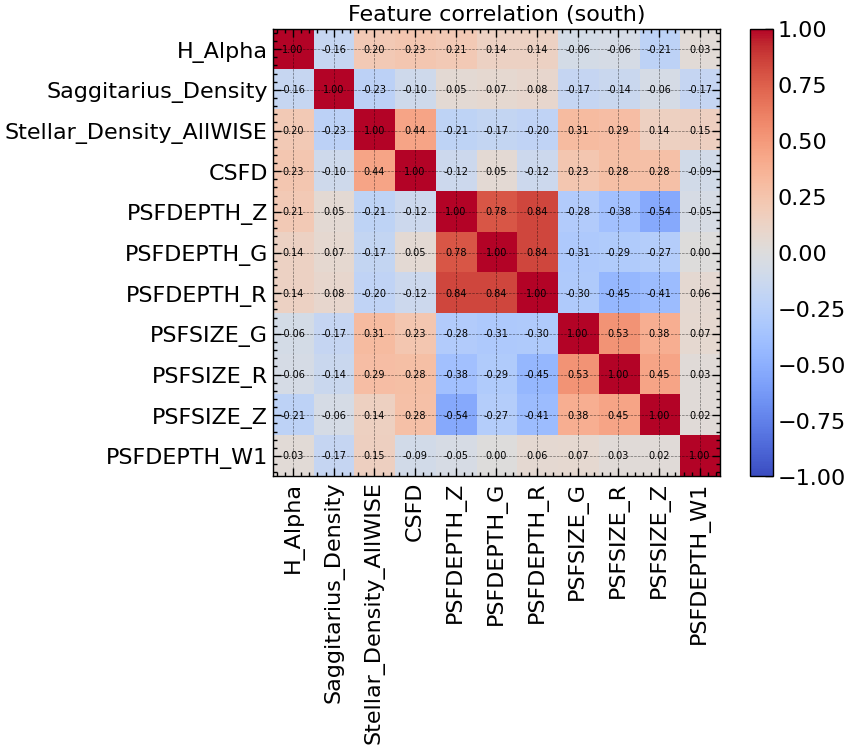

In [16]:
for part in ('north', 'south'):
    X = SW[part].X[:, 1:]          # drop intercept column
    corr = np.corrcoef(X, rowvar=False)
    plt.figure(figsize=(9, 7.5))
    plt.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
    for i in range(len(SYSTEMATICS)):
        for j in range(len(SYSTEMATICS)):
            plt.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', fontsize=7)
    plt.xticks(range(len(SYSTEMATICS)), SYSTEMATICS, rotation=90)
    plt.yticks(range(len(SYSTEMATICS)), SYSTEMATICS)
    plt.title(f'Feature correlation ({part})')
    plt.colorbar(); plt.tight_layout(); plt.show()

## Null tests: overdensity vs systematic, before / after
The decision plot. Same content as the original's big panel, computed by the module
(so the identical test can be rerun per property bin from the w(θ) notebook).

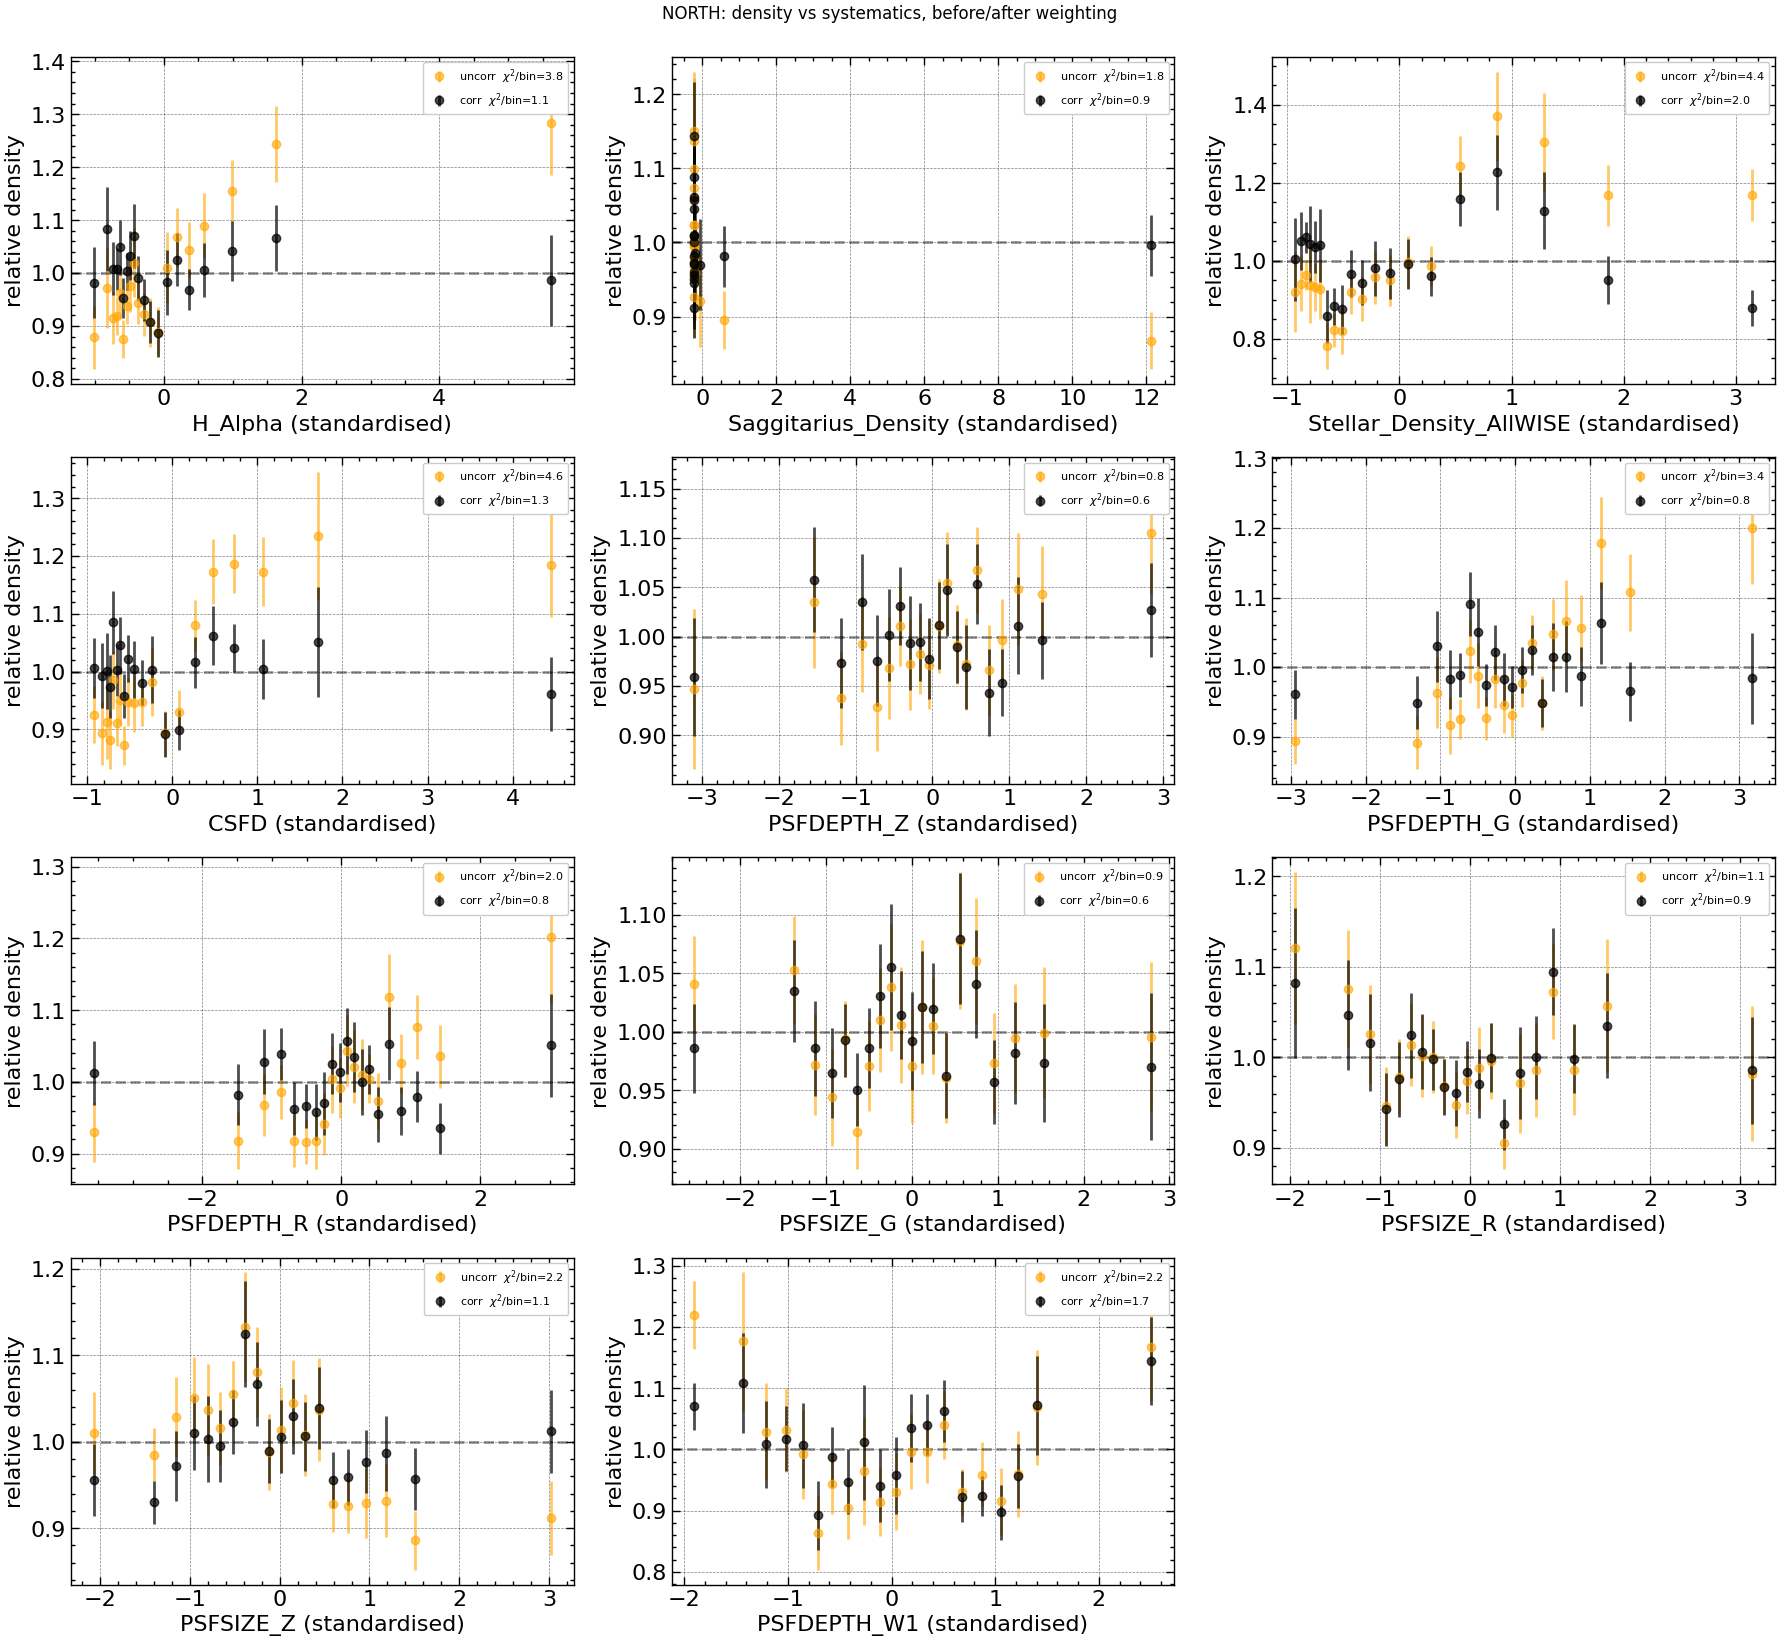

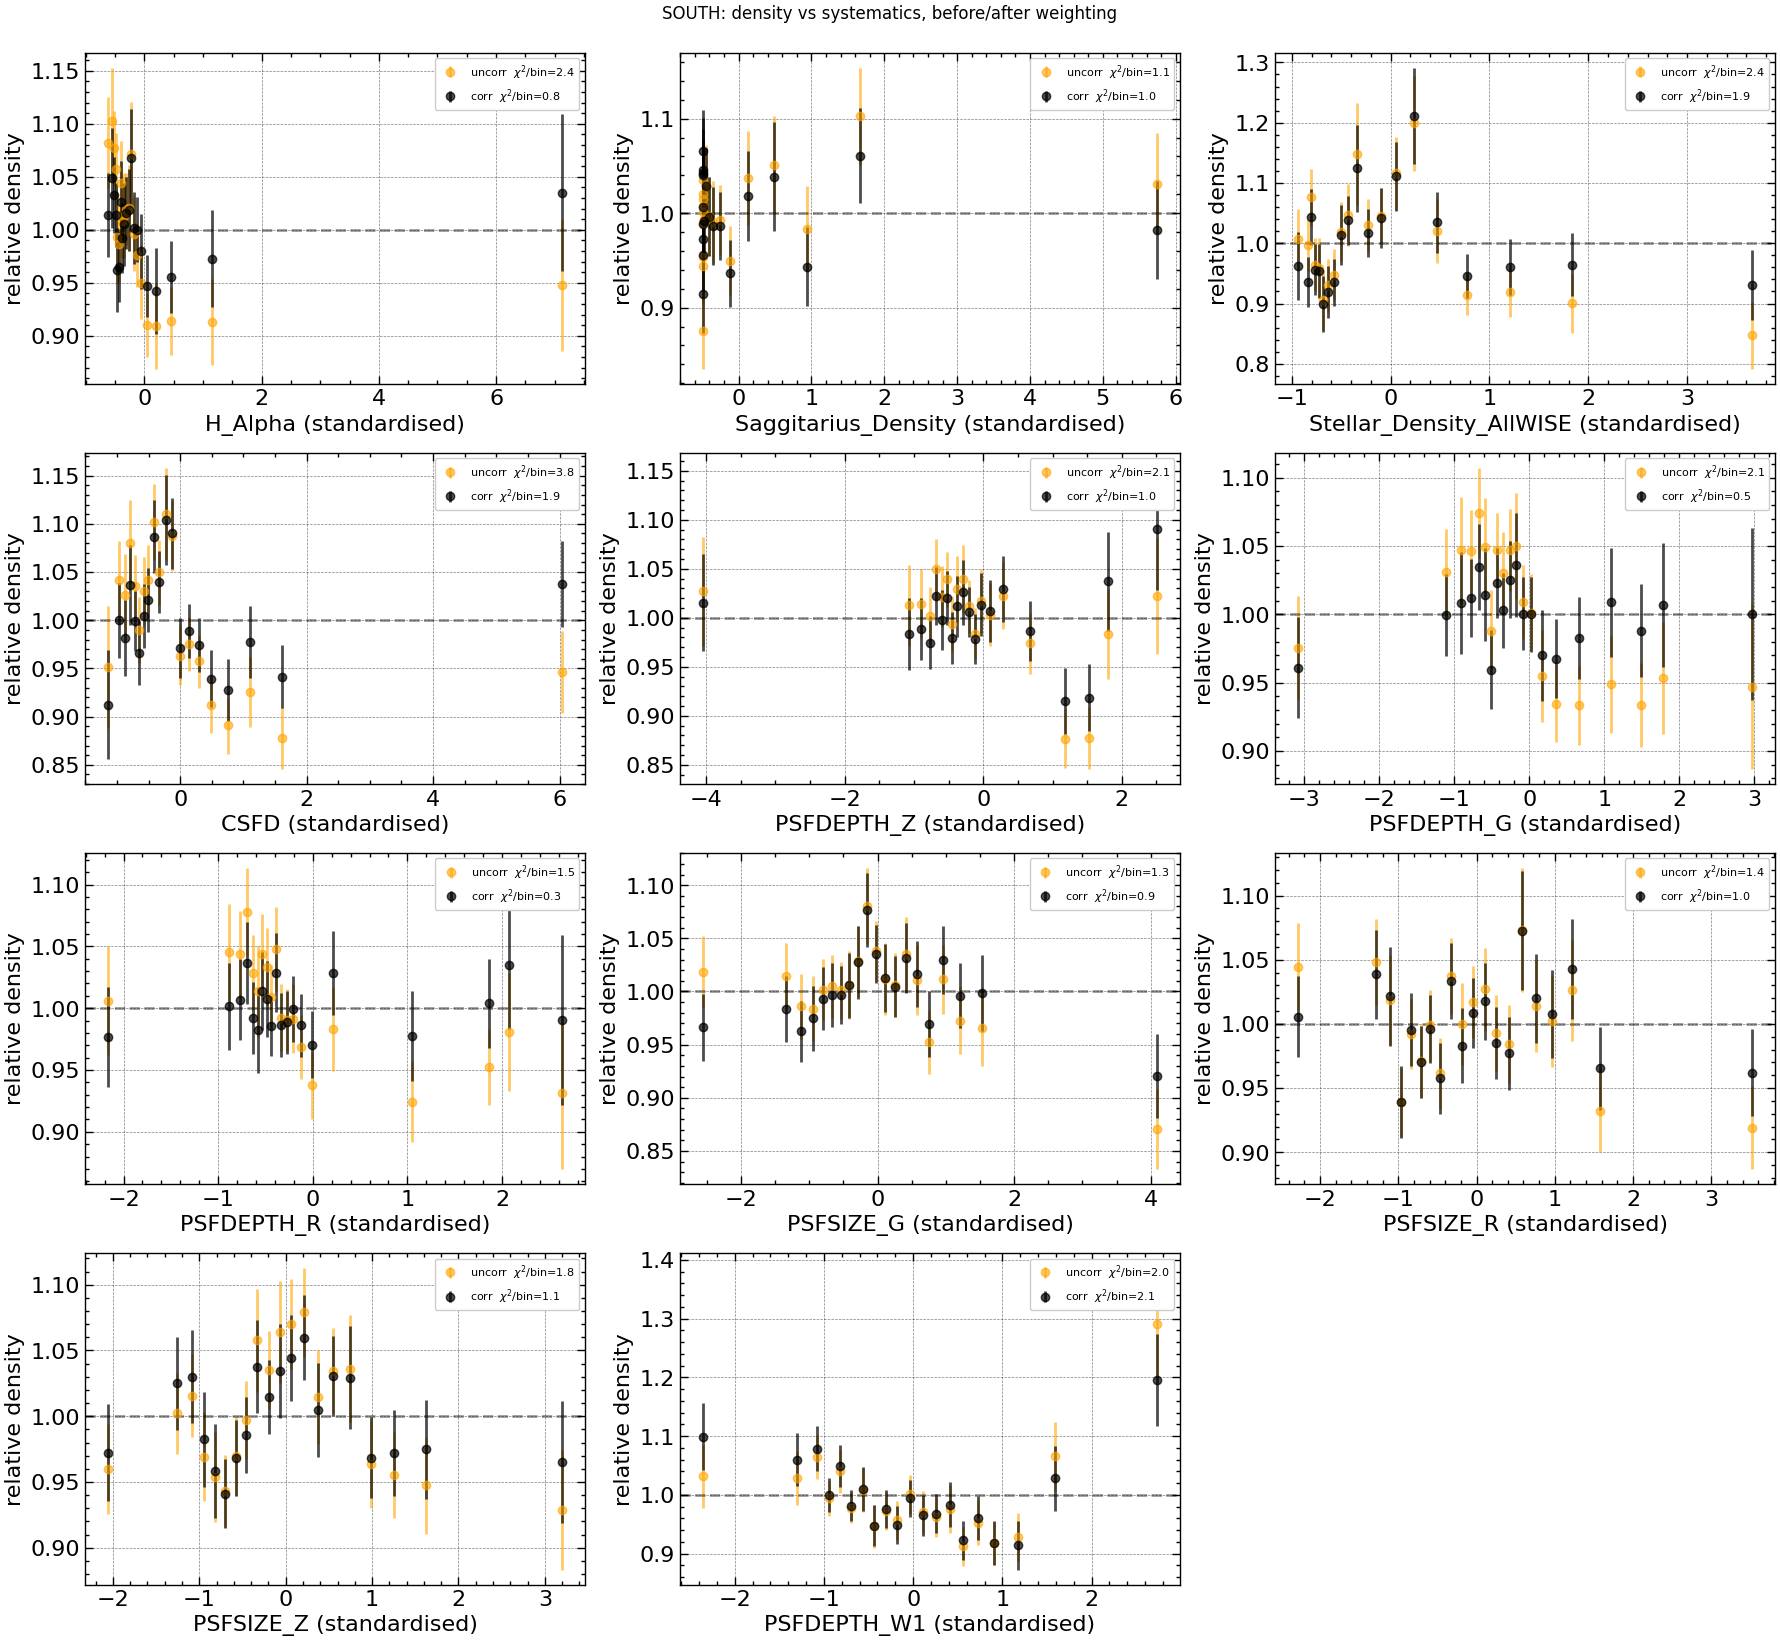

In [17]:
for part in ('north', 'south'):
    reg = (DEC_g >= DEC_SPLIT) if part == 'north' else (DEC_g < DEC_SPLIT)
    nt = SW[part].null_test(FIT[part], RA_g[reg], DEC_g[reg], nbins=20)

    n_sys, n_cols = len(SYSTEMATICS), 3
    n_rows = (n_sys + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.2*n_rows))
    axes = axes.flatten()
    for ax, s in zip(axes, SYSTEMATICS):
        d = nt[s]
        (db, sb, chi2b), (da, sa, chi2a) = d['before'], d['after']
        nb_ = len(d['centers'])
        ax.errorbar(d['centers'], 1+db, yerr=sb, fmt='o', color='orange', alpha=0.6,
                    label=f'uncorr  $\\chi^2$/bin={chi2b/nb_:.1f}')
        ax.errorbar(d['centers'], 1+da, yerr=sa, fmt='o', color='k', alpha=0.7,
                    label=f'corr  $\\chi^2$/bin={chi2a/nb_:.1f}')
        ax.axhline(1, color='k', ls='--', alpha=0.4)
        ax.set_xlabel(f'{s} (standardised)'); ax.set_ylabel('relative density')
        ax.legend(fontsize=8)
    for ax in axes[n_sys:]:
        ax.axis('off')
    fig.suptitle(f'{part.upper()}: density vs systematics, before/after weighting')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig(f'{OUT_DIR}/{part}_nulltests_{WEIGHT_KIND}.png', dpi=200)
    plt.show()

## Extrapolation validation
The panels above test the fit footprint. With `EXTRAPOLATE=True` the decisive test is the
**analysis footprint including the outlier pixels** (`pixels='all'`): the tail bins of each
panel are sky the fit never saw, corrected purely by the model's extension. Flat tails →
extrapolation holds, sky is kept for free. Rising tails or a large clip-saturation fraction →
the model does not extend there; fall back to cutting those pixels (`EXTRAPOLATE=False`) or
add a quadratic term for the offending map.

In [18]:
if EXTRAPOLATE:
    for part in ('north', 'south'):
        reg = (DEC_g >= DEC_SPLIT) if part == 'north' else (DEC_g < DEC_SPLIT)
        nt_all = SW[part].null_test(FIT[part], RA_g[reg], DEC_g[reg],
                                    nbins=20, pixels='all')
        print(f"-- {part.upper()} (analysis footprint incl. outlier pixels) --")
        for s in SYSTEMATICS:
            d = nt_all[s]
            nb_ = len(d['centers'])
            # chi2 in the tail bins (outermost 3 each side) vs the bulk
            da, sa = d['after'][0], d['after'][1]
            tail = np.r_[np.arange(3), np.arange(nb_-3, nb_)]
            bulk = np.arange(3, nb_-3)
            chi2_tail = np.sum((da[tail]/sa[tail])**2)/len(tail)
            chi2_bulk = np.sum((da[bulk]/sa[bulk])**2)/len(bulk)
            flag = '   <-- extrapolation failing here' if chi2_tail > 3*max(chi2_bulk,1) else ''
            print(f"  {s:>28}: chi2/bin bulk={chi2_bulk:5.2f}  tails={chi2_tail:5.2f}{flag}")

-- NORTH (analysis footprint incl. outlier pixels) --
                       H_Alpha: chi2/bin bulk= 1.36  tails= 0.49
           Saggitarius_Density: chi2/bin bulk= 1.04  tails= 0.71
       Stellar_Density_AllWISE: chi2/bin bulk= 2.00  tails= 1.99
                          CSFD: chi2/bin bulk= 1.74  tails= 0.12
                    PSFDEPTH_Z: chi2/bin bulk= 0.63  tails= 0.40
                    PSFDEPTH_G: chi2/bin bulk= 0.74  tails= 0.89
                    PSFDEPTH_R: chi2/bin bulk= 0.84  tails= 0.81
                     PSFSIZE_G: chi2/bin bulk= 0.79  tails= 0.26
                     PSFSIZE_R: chi2/bin bulk= 1.18  tails= 0.35
                     PSFSIZE_Z: chi2/bin bulk= 0.83  tails= 1.86
                   PSFDEPTH_W1: chi2/bin bulk= 1.66  tails= 1.76
-- SOUTH (analysis footprint incl. outlier pixels) --
                       H_Alpha: chi2/bin bulk= 0.78  tails= 0.73
           Saggitarius_Density: chi2/bin bulk= 0.90  tails= 1.18
       Stellar_Density_AllWISE: chi2/bin bulk= 

## Maps and weight histograms

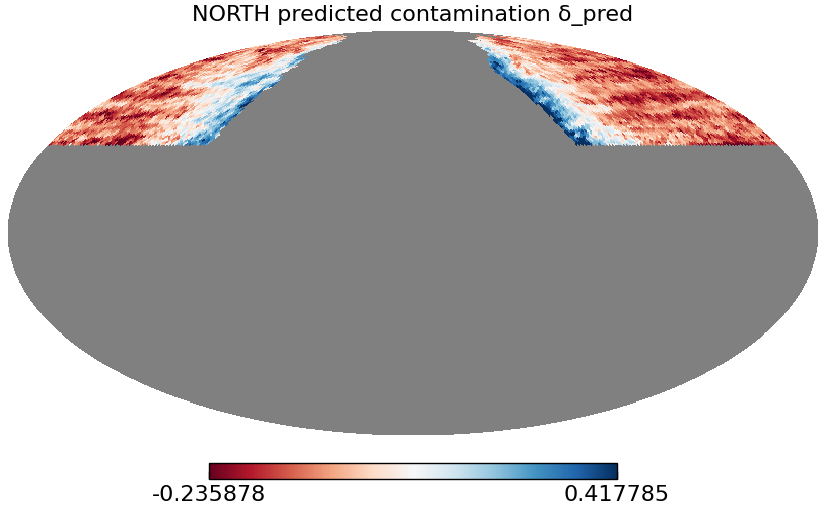

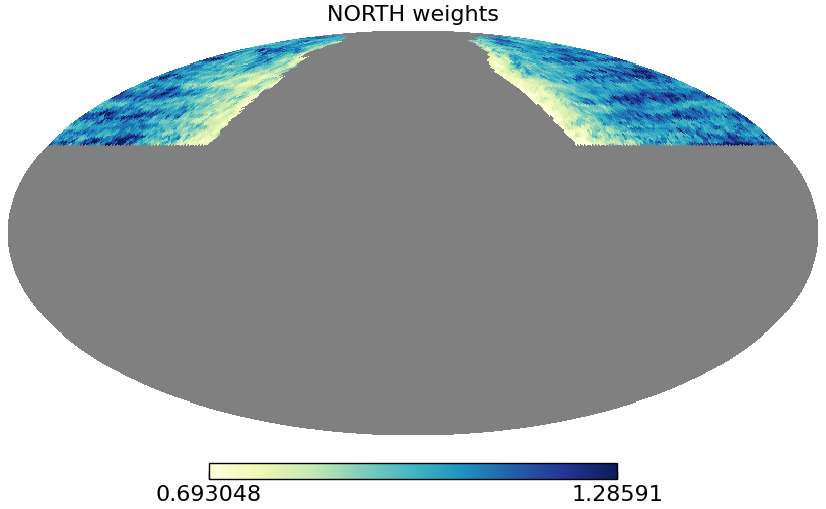

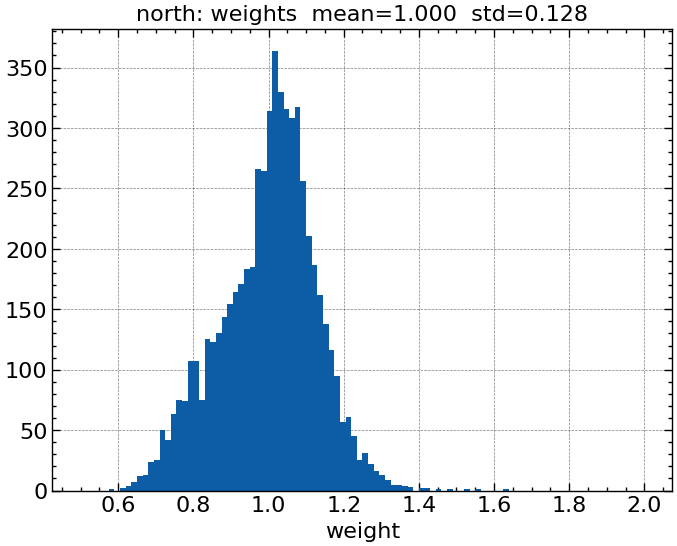

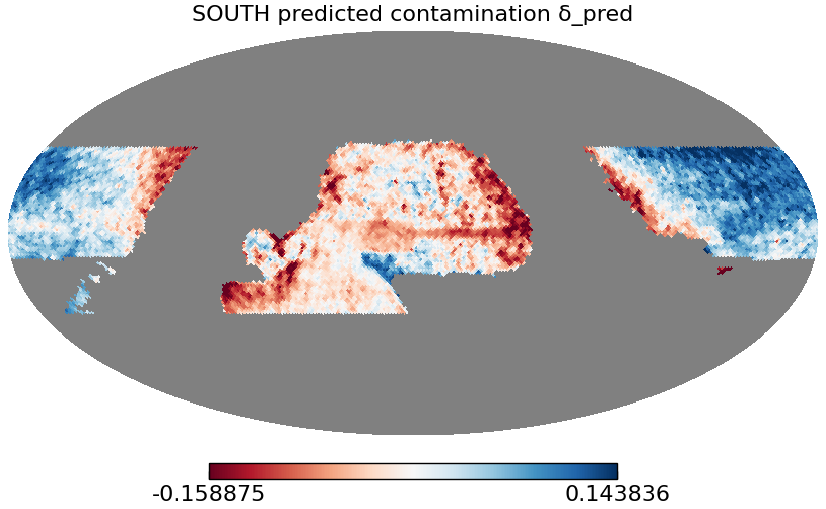

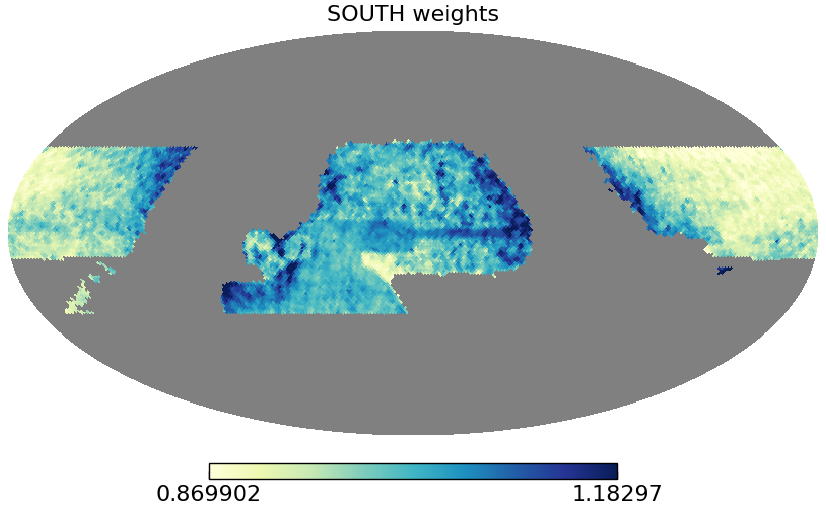

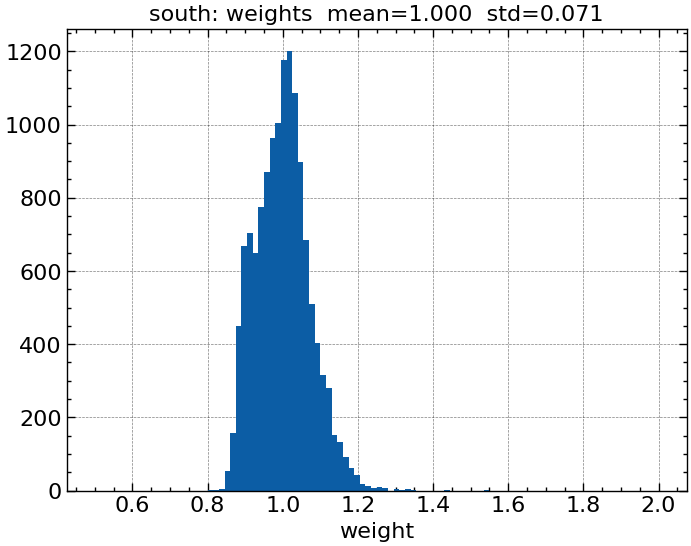

In [19]:
for part in ('north', 'south'):
    f, sw = FIT[part], SW[part]

    pred_map = np.full(sw.npix, np.nan)
    pred_map[sw.fit_pixels] = sw.X @ np.r_[f['intercept'], f['coeffs']]
    hp.mollview(pred_map, title=f'{part.upper()} predicted contamination δ_pred',
                cmap='RdBu', min=np.nanpercentile(pred_map, 1),
                max=np.nanpercentile(pred_map, 99))
    plt.show()

    wmap_plot = np.where(f['fit_pixel_mask'], f['weight_map'], np.nan)
    hp.mollview(wmap_plot, title=f'{part.upper()} weights', cmap='YlGnBu',
                min=np.nanpercentile(wmap_plot, 1), max=np.nanpercentile(wmap_plot, 99))
    plt.show()

    w = f['weight_map'][f['fit_pixel_mask']]
    plt.hist(w, bins=100, range=(0.5, 2))
    plt.title(f'{part}: weights  mean={w.mean():.3f}  std={w.std():.3f}')
    plt.xlabel('weight'); plt.show()

## Save — filenames the w(θ) pipeline actually reads
The original saved to `multilinear_results/{part}/..._new_mask_...` while the clustering
notebook read `{WEIGHT_DIR}/{part}_multilinear_systematic_weights_nside64_{kind}.fits` —
they never matched without manual copying. One canonical location and pattern now, and the
**fit-footprint mask is saved next to each weight map** so the clustering step can cut data
and randoms to the same pixels (galaxies on outlier pixels must be excluded, not silently
given weight 1).

In [20]:
for part in ('north', 'south'):
    f = FIT[part]
    hp.write_map(f'{OUT_DIR}/{part}_multilinear_systematic_weights_nside{NSIDE}_{WEIGHT_KIND}.fits',
                 f['weight_map'], overwrite=True)
    hp.write_map(f'{OUT_DIR}/{part}_fit_footprint_nside{NSIDE}_{WEIGHT_KIND}.fits',
                 f['fit_pixel_mask'].astype(np.float64), overwrite=True)
    hp.write_map(f'{OUT_DIR}/{part}_weight_footprint_nside{NSIDE}_{WEIGHT_KIND}.fits',
                 f['weight_pixel_mask'].astype(np.float64), overwrite=True)
    np.save(f'{OUT_DIR}/{part}_multilinear_coeffs_{WEIGHT_KIND}.npy',
            dict(coefficients=f['coeffs'], errors=f['errors'],
                 intercept=f['intercept'], systematics=SYSTEMATICS,
                 chi2_before=f['chi2_before'], chi2_after=f['chi2_after'],
                 ndof=f['ndof'], dec_split=DEC_SPLIT, ridge=RIDGE,
                 coverage_min=COVERAGE_MIN, outlier_kind=OUTLIER_KIND,
                 extrapolated=EXTRAPOLATE, quadratic=QUADRATIC,
                 limits=SW[part].limits),
            allow_pickle=True)
print(f"Saved weight maps + footprint masks + coefficient records -> {OUT_DIR}")

setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


Saved weight maps + footprint masks + coefficient records -> /user/animesh.sah/DESI_PECVEL/systematic_weights


## Outlier-scheme comparison
Runs the full fit under each outlier-handling scheme — `none` (full sample),
`equal_5`, `equal_10`, `partial_percentile` — in one loop, on both regions, and compares:

1. **retained footprint fraction** — the cost of each scheme in sky area;
2. **coefficients side by side** — scheme-sensitivity of each systematic
   (a coefficient that keeps drifting as the cuts tighten is flagging nonlinearity in
   that systematic's tail, not a "better" fit — CSFD south is the known suspect);
3. **null-test χ² after correction** — whether the weights actually flatten the
   density–systematic relations *on the pixels each scheme retains*;
4. **weight-map agreement on the common footprint** — the number that matters for w(θ):
   if two schemes give near-identical weights where they overlap, the w(θ) difference is
   pure footprint, and the scheme choice is cosmetic.

The verdict cell at the end turns these into per-systematic stability flags.

In [22]:
SCHEMES = {
    'none':               dict(outlier_kind='none'),
    'equal_5':            dict(outlier_kind='equal', outlier_val=5.0),
    'equal_10':           dict(outlier_kind='equal', outlier_val=10.0),
    'partial_percentile': dict(outlier_kind='partial_percentile'),
}

SW_CMP, FIT_CMP = {}, {}
for tag, kw in SCHEMES.items():
    SW_CMP[tag], FIT_CMP[tag] = {}, {}
    for part in ('north', 'south'):
        sw = SysWeights(part=part,
                        mask_path=f'../mask_psf_{part}_nside_64.fits',
                        sys_dir=SYS_DIR,
                        rand_counts_path=f'{SYS_DIR}/{part}_counts_randoms_nside_64.fits',
                        systematics=SYSTEMATICS, nside=NSIDE,
                        coverage_min=COVERAGE_MIN, **kw)
        reg = (DEC_g >= DEC_SPLIT) if part == 'north' else (DEC_g < DEC_SPLIT)
        SW_CMP[tag][part] = sw
        FIT_CMP[tag][part] = sw.fit(RA_g[reg], DEC_g[reg], ridge=RIDGE)

# 1) footprint retention (relative to the no-cut footprint of the same region)
print(f"{'scheme':>20} {'north pix':>12} {'south pix':>12} {'N kept':>8} {'S kept':>8}")
for tag in SCHEMES:
    npx = {p: len(SW_CMP[tag][p].fit_pixels) for p in ('north', 'south')}
    ref = {p: len(SW_CMP['none'][p].fit_pixels) for p in ('north', 'south')}
    print(f"{tag:>20} {npx['north']:>12,} {npx['south']:>12,} "
          f"{npx['north']/ref['north']:>7.1%} {npx['south']/ref['south']:>7.1%}")

              scheme    north pix    south pix   N kept   S kept
                none        6,009       13,393  100.0%  100.0%
             equal_5        3,671        8,115   61.1%   60.6%
            equal_10        2,277        4,859   37.9%   36.3%
  partial_percentile        4,364        9,418   72.6%   70.3%


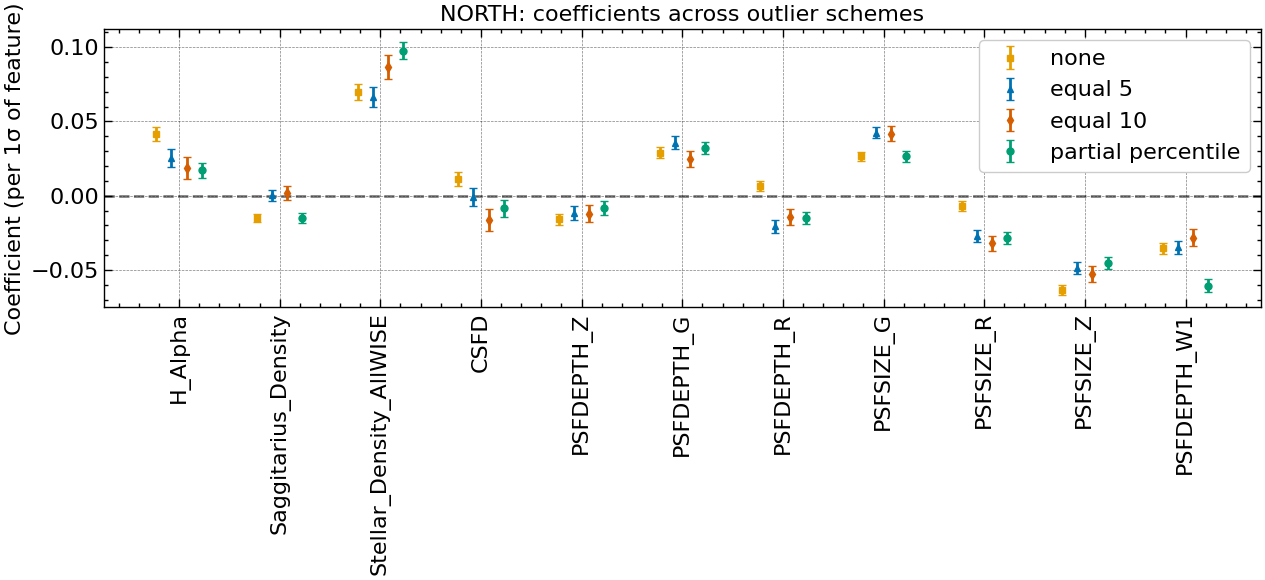

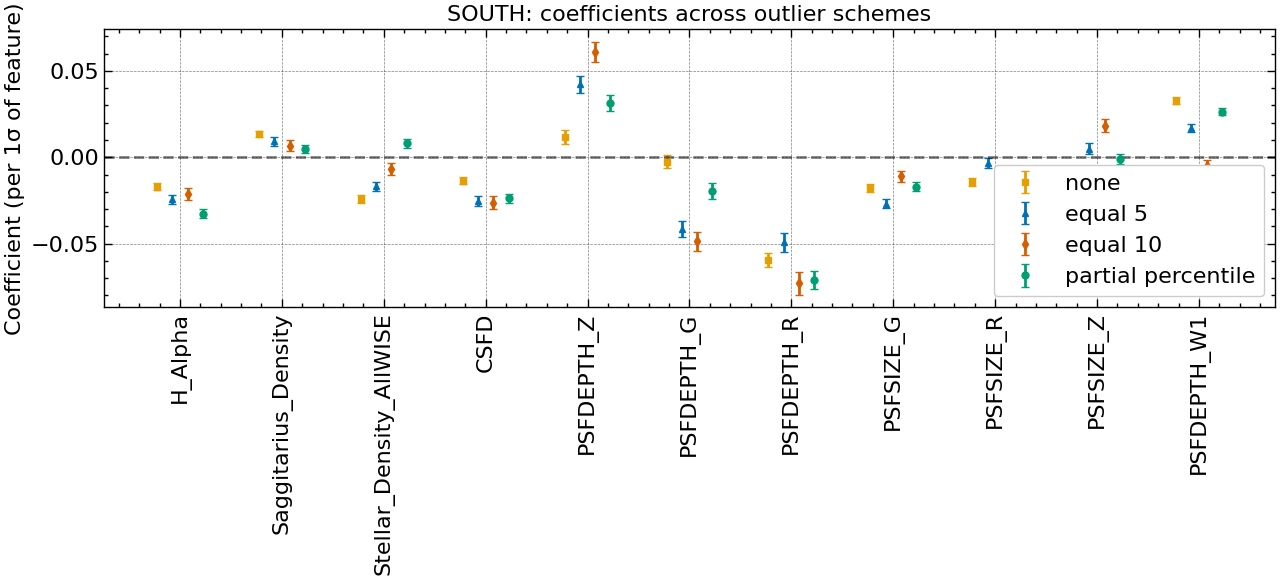

In [23]:
# 2) coefficients side by side (standardised units -> directly comparable)
markers = {'none': 's', 'equal_5': '^', 'equal_10': 'd', 'partial_percentile': 'o'}
colors  = {'none': '#E69F00', 'equal_5': '#0072B2',
           'equal_10': '#D55E00', 'partial_percentile': '#009E73'}
x = np.arange(len(SYSTEMATICS))
for part in ('north', 'south'):
    fig, ax = plt.subplots(figsize=(13, 6))
    for k, tag in enumerate(SCHEMES):
        f = FIT_CMP[tag][part]
        ax.errorbar(x + (k - 1.5) * 0.15, f['coeffs'], yerr=f['errors'],
                    fmt=markers[tag], capsize=3, ms=5, color=colors[tag],
                    label=tag.replace('_', ' '))
    ax.axhline(0, color='k', ls='--', alpha=0.5)
    ax.set_xticks(x); ax.set_xticklabels(SYSTEMATICS, rotation=90)
    ax.set_ylabel('Coefficient (per 1σ of feature)')
    ax.set_title(f'{part.upper()}: coefficients across outlier schemes')
    ax.legend(); plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/{part}_coeff_scheme_comparison.png', dpi=200)
    plt.show()

In [24]:
# 3) null-test chi2/bin after correction, per scheme (its own retained pixels)
print(f"{'':>28}" + ''.join(f"{t:>22}" for t in SCHEMES))
NT_CMP = {}
for part in ('north', 'south'):
    reg = (DEC_g >= DEC_SPLIT) if part == 'north' else (DEC_g < DEC_SPLIT)
    NT_CMP[part] = {tag: SW_CMP[tag][part].null_test(
                        FIT_CMP[tag][part], RA_g[reg], DEC_g[reg], nbins=20)
                    for tag in SCHEMES}
    print(f"-- {part.upper()} --")
    for s in SYSTEMATICS:
        row = f"{s:>28}"
        for tag in SCHEMES:
            d = NT_CMP[part][tag][s]
            row += f"{d['after'][2]/len(d['centers']):>22.2f}"
        print(row)

                                              none               equal_5              equal_10    partial_percentile
-- NORTH --
                     H_Alpha                  1.10                  1.27                  2.14                  1.33
         Saggitarius_Density                  0.94                  1.09                  1.13                  1.12
     Stellar_Density_AllWISE                  2.00                  1.61                  1.31                  1.39
                        CSFD                  1.26                  1.44                  1.22                  1.55
                  PSFDEPTH_Z                  0.56                  0.76                  0.80                  0.60
                  PSFDEPTH_G                  0.78                  1.27                  0.48                  1.00
                  PSFDEPTH_R                  0.83                  0.79                  0.74                  1.07
                   PSFSIZE_G                  0.63  


NORTH: common footprint = 2,277 pixels
                  none vs partial_percentile:  rms Δw = 0.0409   max |Δw| = 0.146
               equal_5 vs partial_percentile:  rms Δw = 0.0342   max |Δw| = 0.145
              equal_10 vs partial_percentile:  rms Δw = 0.0410   max |Δw| = 0.163


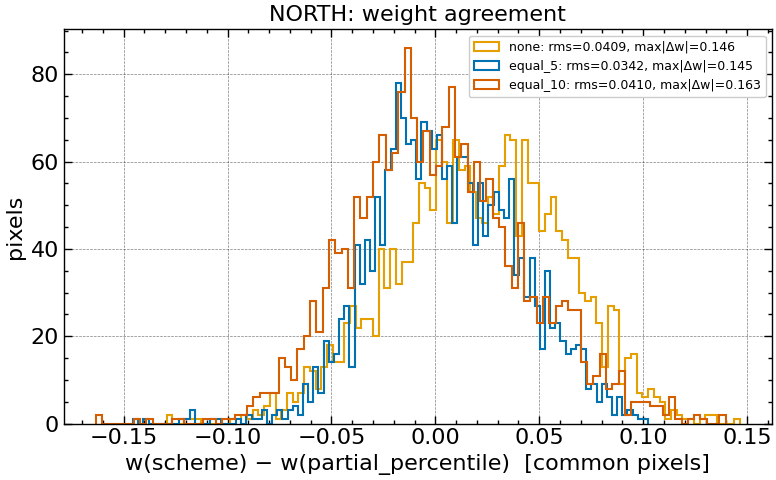


SOUTH: common footprint = 4,859 pixels
                  none vs partial_percentile:  rms Δw = 0.0365   max |Δw| = 0.331
               equal_5 vs partial_percentile:  rms Δw = 0.0294   max |Δw| = 0.152
              equal_10 vs partial_percentile:  rms Δw = 0.0486   max |Δw| = 0.246


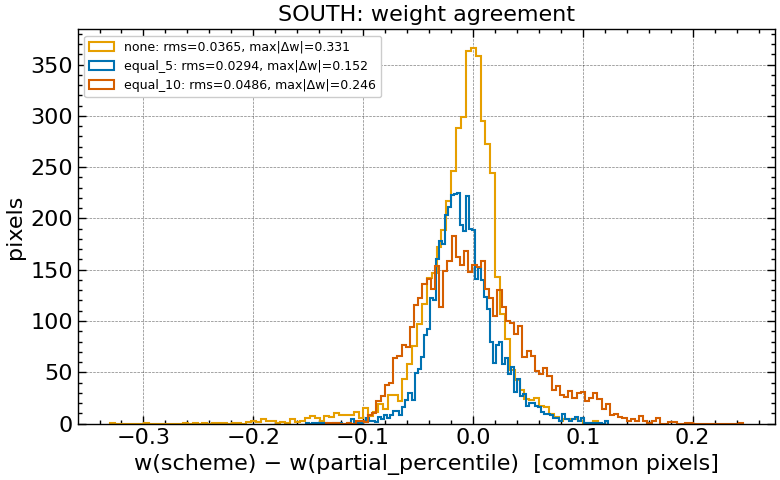

In [25]:
# 4) weight agreement on the COMMON footprint (intersection of all schemes' fit pixels)
for part in ('north', 'south'):
    common = np.ones(hp.nside2npix(NSIDE), dtype=bool)
    for tag in SCHEMES:
        common &= FIT_CMP[tag][part]['fit_pixel_mask']
    print(f"\n{part.upper()}: common footprint = {common.sum():,} pixels")

    ref_tag = 'partial_percentile'
    wref = FIT_CMP[ref_tag][part]['weight_map'][common]
    fig, ax = plt.subplots(figsize=(8, 5))
    for tag in SCHEMES:
        if tag == ref_tag:
            continue
        dw = FIT_CMP[tag][part]['weight_map'][common] - wref
        ax.hist(dw, bins=100, histtype='step', lw=1.5, color=colors[tag],
                label=f"{tag}: rms={dw.std():.4f}, max|Δw|={np.abs(dw).max():.3f}")
        print(f"  {tag:>20} vs {ref_tag}:  rms Δw = {dw.std():.4f}   "
              f"max |Δw| = {np.abs(dw).max():.3f}")
    ax.set_xlabel(f'w(scheme) − w({ref_tag})  [common pixels]')
    ax.set_ylabel('pixels'); ax.set_title(f'{part.upper()}: weight agreement')
    ax.legend(fontsize=9); plt.tight_layout(); plt.show()

In [26]:
# Verdict: per-systematic coefficient stability across schemes.
# 'drift' = max pairwise coefficient difference in units of the largest error.
# drift < ~2: scheme choice doesn't matter for this systematic.
# drift >> 2 and monotone with cut severity: nonlinear tail -> fix with a physical
# cut or a quadratic term, not by picking the scheme with the prettiest chi2.
for part in ('north', 'south'):
    print(f"\n-- {part.upper()} --")
    print(f"{'systematic':>28} {'drift/sigma':>12}   flag")
    for i, s in enumerate(SYSTEMATICS):
        cs = np.array([FIT_CMP[t][part]['coeffs'][i] for t in SCHEMES])
        es = np.array([FIT_CMP[t][part]['errors'][i] for t in SCHEMES])
        drift = (cs.max() - cs.min()) / es.max()
        flag = '' if drift < 2 else ('  <-- scheme-sensitive' if drift < 5
                                     else '  <-- NONLINEAR TAIL: physical cut / quadratic term')
        print(f"{s:>28} {drift:>12.1f}{flag}")


-- NORTH --
                  systematic  drift/sigma   flag
                     H_Alpha          3.4  <-- scheme-sensitive
         Saggitarius_Density          3.5  <-- scheme-sensitive
     Stellar_Density_AllWISE          3.8  <-- scheme-sensitive
                        CSFD          3.7  <-- scheme-sensitive
                  PSFDEPTH_Z          1.3
                  PSFDEPTH_G          2.0
                  PSFDEPTH_R          5.0  <-- scheme-sensitive
                   PSFSIZE_G          3.2  <-- scheme-sensitive
                   PSFSIZE_R          4.9  <-- scheme-sensitive
                   PSFSIZE_Z          3.4  <-- scheme-sensitive
                 PSFDEPTH_W1          5.6  <-- NONLINEAR TAIL: physical cut / quadratic term

-- SOUTH --
                  systematic  drift/sigma   flag
                     H_Alpha          4.7  <-- scheme-sensitive
         Saggitarius_Density          2.7  <-- scheme-sensitive
     Stellar_Density_AllWISE          8.8  <-- NONLINEAR TA

### Reading the verdict
- If `partial_percentile` and `equal_5` agree on the common footprint (small rms Δw) **and**
  both pass the null tests, keep `partial_percentile` as the fiducial and quote the
  w(θ) difference between the two as the outlier-handling systematic band.
- `none` disagreeing with everything is expected and is the argument *for* cutting.
- `equal_10` buys little beyond `equal_5` while costing ~2× the sky — include it in the
  comparison, not in the analysis.
- Any systematic flagged NONLINEAR TAIL: freeze its cut at a physical value
  (`SW[part].limits` has the realised thresholds) and consider a quadratic term, then rerun.